# LAB08 — Koha e Reagimit: Të Dhëna, Shpërndarje dhe Probabilitet
---
- ##### Tema: **Matja e kohës së reagimit me metodën e rënies së vizores.**
- ##### Studenti: Florian Loka
- ##### Pedagogu: Ervin Kafexhiu
- ##### Data: 05.05.2026
---


## **Qëllimi (Purpose)**

Ky laborator tregon se rezultatet eksperimentale nuk përshkruhen gjithmonë nga një
**vlerë e vetme**, por nga një **shpërndarje probabilitare**. Konkretisht:

- Mbledhim një numër të madh matjesh të kohës së reagimit (≥ 30 për person).
- Ndërtojmë **histogramin** dhe e normalizojmë si densitet probabiliteti.
- Krahasojmë shpërndarjen empirike me një model **Gaussian**.
- Raportojmë rezultatin si \(t = \bar{t} \pm \sigma\) dhe e interpretojmë.


## **Hyrje Teorike (Theory)**

Koha e reagimit është një madhësi **statistikore**: ndryshon nga matja në matje.
Me metodën e *rënies së vizores*, personi kap një vizore që bie lirisht; nga
distanca e rënies $d$ përcaktohet koha:

$$ d = \tfrac{1}{2} g t^2 \;\;\Rightarrow\;\; t = \sqrt{\frac{2d}{g}}, \qquad g \approx 9.81\ \mathrm{m/s^2} $$

Madhësitë statistikore bazë janë mesatarja dhe devijimi standard:

$$ \bar{t} = \frac{1}{N}\sum_i t_i \qquad
\sigma = \sqrt{\frac{1}{N-1}\sum_i (t_i-\bar{t})^2} $$

Një shpërndarje e vazhdueshme që e përshkruan mirë këtë lloj të dhënash është ajo
**normale (Gaussiane)**:

$$ f(t) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(t-\bar{t})^2}{2\sigma^2}\right) $$


## **Aparatura dhe Pajisjet (Apparatus)**

| Pajisja | Roli | Saktësia |
|---------|------|----------|
| Vizore (≥ 50 cm) | matja e distancës së rënies \(d\) | 0.1 cm |
| Dy persona | njëri lëshon, tjetri kap | — |
| Jupyter Notebook | regjistrimi dhe analiza | — |

Matjet ruhen në `data/reagimi.csv`.


## **Procedura (Procedure)**

1. Personi A mban vizoren vertikalisht; personi B vendos gishtat te shenja 0.
2. Pa paralajmërim, A lëshon vizoren; B e kap sa më shpejt.
3. Lexohet distanca \(d\) (cm) ku u kap vizorja.
4. Përsëritet **≥ 40 herë për person**, duke regjistruar çdo \(d\).
5. Distancat konvertohen në kohë \(t=\sqrt{2d/g}\) dhe analizohen statistikisht.


## **Përpunimi Paraprak i të Dhënave (Preprocessing)**

Ngarkojmë matjet nga `data/`, i ndajmë sipas personit dhe konvertojmë distancën në kohë.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
g = 9.81  # m/s^2

df = pd.read_csv("data/reagimi.csv")
df["t_s"] = np.sqrt(2 * (df["d_cm"]/100.0) / g)   # cm -> m -> s
print("Numri total i matjeve:", len(df))
print(df.groupby("person")["t_s"].agg(["count", "mean", "std"]).round(4))

Numri total i matjeve: 80
            count    mean     std
person                           
Aleksandro     40  0.2016  0.0333
Horgito        40  0.1877  0.0303


## **Analiza e të Dhënave (Analysis)**

Llogarisim mesataren, devijimin standard dhe gabimin e mesatares për secilin person,
dhe ndërtojmë histogramin e normalizuar me kurbën Gaussiane përkatëse.

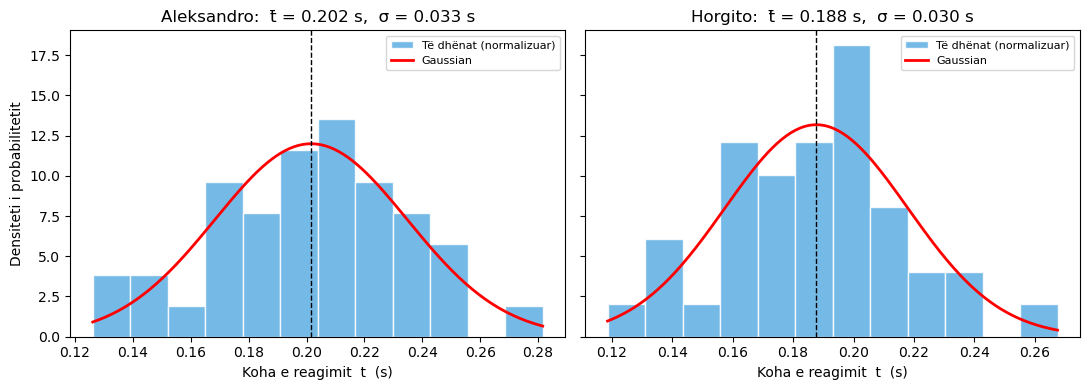

In [2]:
def gauss(x, mu, sd):
    return np.exp(-(x-mu)**2 / (2*sd**2)) / (sd*np.sqrt(2*np.pi))

stats = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (person, grp) in zip(axes, df.groupby("person")):
    t = grp["t_s"].to_numpy()
    mu, sd = t.mean(), t.std(ddof=1)
    sem = sd/np.sqrt(len(t))          # gabimi i mesatares
    stats[person] = (mu, sd, sem, len(t))

    ax.hist(t, bins=12, density=True, color="#5dade2", edgecolor="white", alpha=0.85,
            label="Të dhënat (normalizuar)")
    xs = np.linspace(t.min(), t.max(), 200)
    ax.plot(xs, gauss(xs, mu, sd), "r-", lw=2, label="Gaussian")
    ax.axvline(mu, color="k", ls="--", lw=1)
    ax.set_title(f"{person}:  t̄ = {mu:.3f} s,  σ = {sd:.3f} s")
    ax.set_xlabel("Koha e reagimit  t  (s)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Densiteti i probabilitetit")
fig.tight_layout()
fig.savefig(FIGS / "histogrami_reagimit.png", dpi=150)
plt.show()

## **Analiza e Pasigurisë (Uncertainty)**

Gjerësia e shpërndarjes jepet nga $\sigma$. Pasiguria e **mesatares** zvogëlohet me
numrin e matjeve:

$$ \mathrm{SEM} = \frac{\sigma}{\sqrt{N}} $$

Pra, sa më shumë matje, aq më e saktë mesatarja — por $\sigma$ (variacioni individual)
mbetet veti reale e personit, jo gabim që zhduket.

In [3]:
print(f"{'Personi':<12}{'N':>4}{'t̄ (s)':>10}{'σ (s)':>9}{'SEM (s)':>10}")
for p,(mu,sd,sem,n) in stats.items():
    print(f"{p:<12}{n:>4}{mu:>10.3f}{sd:>9.3f}{sem:>10.4f}")

Personi        N    t̄ (s)    σ (s)   SEM (s)
Aleksandro    40     0.202    0.033    0.0053
Horgito       40     0.188    0.030    0.0048


## **Rezultatet (Results)**

Rezultati për secilin person jepet në formën \(t = (\bar{t} \pm \sigma)\) s.

In [4]:
for p,(mu,sd,sem,n) in stats.items():
    print(f"{p}:  t = ({mu:.3f} ± {sd:.3f}) s   (gabimi i mesatares ± {sem:.4f} s)")

Aleksandro:  t = (0.202 ± 0.033) s   (gabimi i mesatares ± 0.0053 s)
Horgito:  t = (0.188 ± 0.030) s   (gabimi i mesatares ± 0.0048 s)


## **Diskutimi (Discussion)**

- **Pse koha e reagimit nuk është konstante?** Ajo varet nga procese neuro-muskulare
  që ndryshojnë nga prova në provë; prandaj rezultati është një shpërndarje, jo një numër.
- **Çfarë përcakton gjerësinë e shpërndarjes?** Devijimi standard \(\sigma\) —
  sa i qëndrueshëm është personi. Persona të ndryshëm kanë \(\sigma\) të ndryshme.
- **A përmirësohet rezultati me më shumë matje?** Mesatarja bëhet më e saktë
  (SEM \(\propto 1/\sqrt{N}\)), por \(\sigma\) nuk zvogëlohet — ai është veti e personit.
- **Sa mirë përputhet me Gaussianin?** Histogrami ndjek përafërsisht formën Gaussiane,
  me njëfarë anësie (asimetrie) drejt kohëve të mëdha, tipike për kohët e reagimit.


## **Përfundimi (Conclusion)**

Matja e kohës së reagimit konfirmon idenë themelore: **shumë madhësi eksperimentale
janë në thelb statistikore** dhe përshkruhen nga një shpërndarje probabilitare, jo nga
një vlerë e vetme. E raportuam rezultatin si \(t=(\bar t\pm\sigma)\), e vizualizuam
me histogram të normalizuar dhe e krahasuam me modelin Gaussian. Numri i madh i matjeve
ishte thelbësor për të nxjerrë në pah formën e shpërndarjes.
